In [12]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Paso 1. Carga del fichero

Lectura de datos

In [25]:
df = pl.scan_parquet("../data/modeling/base_modelado.parquet")

Tamaño de los datos recolectados

In [26]:
print(df.collect().shape)

(40521392, 24)


Estructura interna de los datos

In [28]:
df.schema

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20288\3182147272.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  df.schema


Schema([('id_sensor', Int32),
        ('id_fecha', Date),
        ('hora', Int32),
        ('intensidad_media', Float64),
        ('intensidad_max', Float64),
        ('intensidad_min', Float64),
        ('ocupacion_media', Float64),
        ('ocupacion_max', Float64),
        ('velocidad_media', Float64),
        ('velocidad_min', Float64),
        ('num_mediciones', Int64),
        ('num_error_E', Float64),
        ('porcentaje_calidad', Float64),
        ('año', Int64),
        ('mes', Int64),
        ('nombre_mes', String),
        ('trimestre', Int64),
        ('dia', Int64),
        ('dia_semana', Int64),
        ('fin_semana', Boolean),
        ('tipo_elem', String),
        ('distrito', Int32),
        ('latitud', Float64),
        ('longitud', Float64)])

Visualización de los 5 primeros registros

In [29]:
df.head().collect()

id_sensor,id_fecha,hora,intensidad_media,intensidad_max,intensidad_min,ocupacion_media,ocupacion_max,velocidad_media,velocidad_min,num_mediciones,num_error_E,porcentaje_calidad,año,mes,nombre_mes,trimestre,dia,dia_semana,fin_semana,tipo_elem,distrito,latitud,longitud
i32,date,i32,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,i64,i64,str,i64,i64,i64,bool,str,i32,f64,f64
4616,2026-04-01,22,98.75,123.0,78.0,1.5,2.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,1,3,false,"""URB""",5,40.472819,-3.685712
4616,2026-04-08,10,301.75,363.0,214.0,5.5,6.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,8,3,false,"""URB""",5,40.472819,-3.685712
4616,2026-04-21,4,23.333333,30.0,14.0,0.666667,1.0,0.0,0.0,3,0.0,100.0,2026,4,"""April""",2,21,2,false,"""URB""",5,40.472819,-3.685712
4616,2026-04-30,3,26.0,33.0,20.0,1.0,2.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,30,4,false,"""URB""",5,40.472819,-3.685712
4616,2026-04-30,15,282.75,329.0,258.0,4.5,5.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,30,4,false,"""URB""",5,40.472819,-3.685712


Visualización de la distribución de los datos

In [31]:
df.collect().describe()

statistic,id_sensor,id_fecha,hora,intensidad_media,intensidad_max,intensidad_min,ocupacion_media,ocupacion_max,velocidad_media,velocidad_min,num_mediciones,num_error_E,porcentaje_calidad,año,mes,nombre_mes,trimestre,dia,dia_semana,fin_semana,tipo_elem,distrito,latitud,longitud
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str,f64,f64,f64
"""count""",4.0521392e7,"""40521392""",4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,"""40521392""",4.0521392e7,4.0521392e7,4.0521392e7,4.0521392e7,"""40521392""",4.0521392e7,4.0521392e7,4.0521392e7
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0
"""mean""",6794.155899,"""2025-12-30 16:06:56.105902""",11.520612,334.255552,383.585398,287.305949,5.236373,7.375898,5.116786,4.755918,3.960639,0.0,99.517551,2025.499504,6.503937,null,2.50404,15.747258,2.999349,0.281935,null,10.287664,40.430422,-3.684039
"""std""",2677.698222,null,6.917672,576.100512,629.976612,528.555676,9.319953,11.967622,18.415437,17.488734,0.278023,0.0,6.845825,0.5,3.448665,null,1.115256,8.765745,1.992627,null,null,5.38041,0.038802,0.042648
"""min""",1001.0,"""2025-07-01""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2025.0,1.0,"""April""",1.0,1.0,0.0,0.0,"""M30""",0.0,40.332454,-3.836886
"""25%""",4693.0,"""2025-09-30""",6.0,47.5,63.0,32.0,0.5,1.0,0.0,0.0,4.0,0.0,100.0,2025.0,4.0,null,2.0,8.0,1.0,null,null,6.0,40.39921,-3.712531
"""50%""",5989.0,"""2025-12-31""",12.0,150.5,184.0,118.0,2.25,3.0,0.0,0.0,4.0,0.0,100.0,2025.0,7.0,null,3.0,16.0,3.0,null,null,10.0,40.43189,-3.68692
"""75%""",10111.0,"""2026-04-02""",18.0,387.5,450.0,328.0,5.75,8.0,0.0,0.0,4.0,0.0,100.0,2026.0,10.0,null,4.0,23.0,5.0,null,null,15.0,40.459606,-3.656483
"""max""",11541.0,"""2026-06-30""",23.0,91368.333333,93520.0,91034.0,100.0,100.0,246.0,246.0,4.0,0.0,100.0,2026.0,12.0,"""September""",4.0,31.0,6.0,1.0,"""other""",21.0,40.515611,-3.551623


# Analisis Bivariado

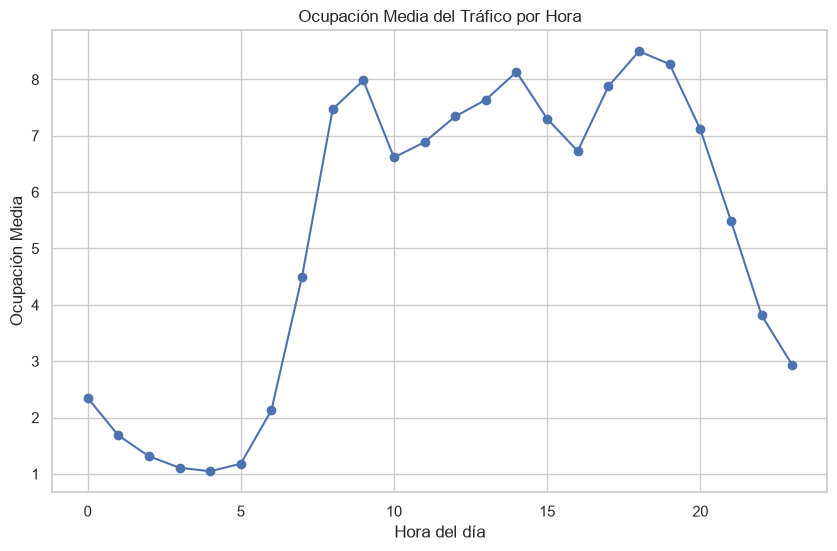

In [13]:
df_resumen = (
    df.group_by('hora')
    .agg(pl.col('ocupacion_media').mean())
    .sort('hora')
    .collect()
)

plt.plot(df_resumen['hora'], df_resumen['ocupacion_media'], marker='o')
plt.title('Ocupación Media del Tráfico por Hora')
plt.xlabel('Hora del día')
plt.ylabel('Ocupación Media')
plt.show()

### Análisis de Ocupación Horaria (Tendencia Central)

Este gráfico de líneas ilustra la **evolución de la ocupación media del tráfico a lo largo de 24 horas**, resumiendo el volumen de la ciudad en una única métrica por hora. Visualiza de forma muy nítida el comportamiento habitual de la movilidad urbana mediante una clásica curva bimodal.

**Patrones Clave Identificados:**

*   **Valle Nocturno (00:00 - 05:00):** La ocupación cae a sus niveles mínimos absolutos, estabilizándose en torno al 1% entre las 03:00 y las 04:00 de la madrugada, reflejando el periodo de mínima actividad en la red viaria.
*   **Pico Matutino (06:00 - 09:00):** Se observa una escalada drástica que coincide con los desplazamientos diarios hacia los centros de trabajo y estudio, alcanzando un primer gran pico del 8% a las 09:00.
*   **Meseta Diurna (10:00 - 16:00):** Tras la hora punta matutina, la ocupación desciende momentáneamente, pero mantiene una tendencia alcista constante impulsada por la actividad comercial, logística y de servicios durante las horas centrales.
*   **Pico Vespertino (17:00 - 19:00):** Es el momento de máxima carga general de la jornada (operación retorno). La ocupación media alcanza su máximo absoluto (cerca del 8.5%) a las 18:00 horas, tras lo cual inicia un descenso rápido y pronunciado hacia la franja nocturna.

**Conclusión:** A diferencia del diagrama de cajas, esta representación colapsa la dispersión para destacar la *tendencia general*, confirmando que la ciudad se rige por horarios laborales estrictos, siendo el retorno vespertino ligeramente más denso que la ida matutina.

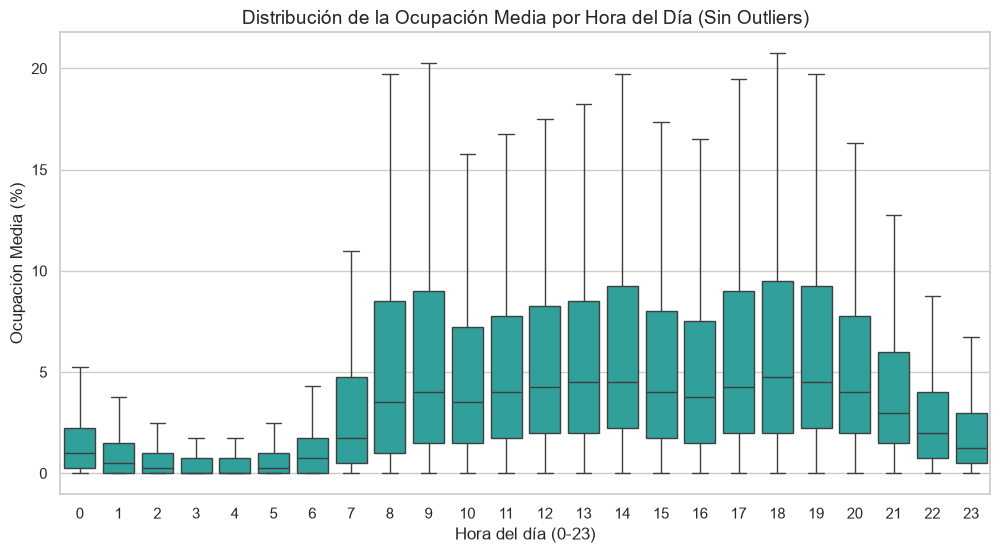

In [14]:
plt.figure(figsize=(12, 6))

data_plot = df.select(['hora', 'ocupacion_media']).collect().to_pandas()

sns.boxplot(
    data=data_plot,
    x='hora',
    y='ocupacion_media',
    color='lightseagreen',
    showfliers=False
)
plt.title('Distribución de la Ocupación Media por Hora del Día (Sin Outliers)', fontsize=14)
plt.xlabel('Hora del día (0-23)')
plt.ylabel('Ocupación Media (%)')
plt.show()

### Análisis de la Distribución y Variabilidad Horaria (Sin Outliers)

Este diagrama de cajas (*boxplot*) profundiza en el análisis al mostrar la **distribución completa y la dispersión espacial** de la ocupación para cada hora del día. A diferencia del gráfico de líneas anterior, este enfoque revela la gran heterogeneidad que existe entre los diferentes puntos de medición de la ciudad.

**Puntos Analíticos Clave:**

*   **Heterogeneidad en Horas Punta (Tamaño de las Cajas):** Durante las franjas de mayor tráfico (08:00-09:00 y 17:00-19:00), las cajas verdes son notablemente más altas (mayor Rango Intercuartílico - IQR). Esto demuestra que el tráfico se vuelve muy desigual en la ciudad: mientras algunas calles secundarias permanecen fluidas (cerca del 0%), las grandes arterias alcanzan niveles críticos de carga.
*   **Techo de Ocupación Típica (Bigotes Superiores):** Los bigotes superiores marcan el límite de lo que se considera "comportamiento normal" antes de entrar en la categoría de valores atípicos. En las horas de mayor congestión (especialmente a las 18:00), estos bigotes rozan el **20% o 21% de ocupación**, identificando el impacto real en los puntos más saturados de la red viaria.
*   **Homogeneidad Nocturna (01:00 - 05:00):** Durante la madrugada, las cajas y los bigotes están completamente comprimidos cerca del eje cero. Esto indica un comportamiento plano y uniforme en toda la ciudad; prácticamente ningún sensor registra actividad relevante en este periodo.
*   **La Meseta del Mediodía:** Entre las 11:00 y las 14:00, las medianas se mantienen estables en torno al 4%, pero la dispersión (altura de las cajas) sigue siendo alta, confirmando que la actividad comercial y el tránsito interurbano mantienen vivas las diferencias entre calles.

**Conclusión:** Este gráfico demuestra que analizar únicamente el "promedio" es insuficiente. La movilidad urbana es un fenómeno asimétrico donde la congestión diurna se concentra fuertemente en ejes específicos, mientras que gran parte de la red vial secundaria permanece despejada.

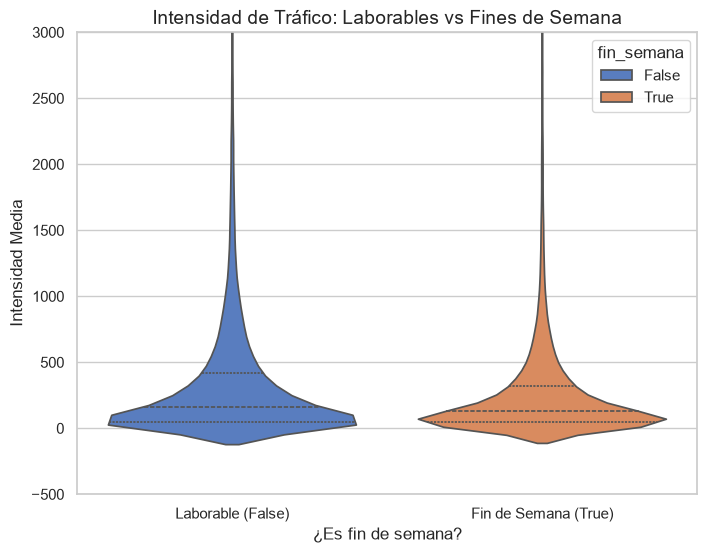

In [34]:
plt.figure(figsize=(8, 6))

data_plot = df.select(['fin_semana', 'intensidad_media']).collect().sample(n=100000)


sns.violinplot(
    data=data_plot, 
    x='fin_semana', 
    y='intensidad_media', 
    inner="quartile", 
    hue='fin_semana', 
    palette="muted"
)

plt.ylim(-500, 3000)
plt.title('Intensidad de Tráfico: Laborables vs Fines de Semana', fontsize=14)
plt.xlabel('¿Es fin de semana?')
plt.ylabel('Intensidad Media')
plt.xticks([0, 1], ['Laborable (False)', 'Fin de Semana (True)'])
plt.show()

### Análisis Comparativo de Densidad: Laborables vs. Fines de Semana

Este gráfico de violín (*violin plot*) contrasta la distribución de la intensidad media del tráfico según la tipología del día. Al recortar el eje Y para aislar los valores atípicos extremos, la visualización revela claramente cómo cambia la estructura base de la movilidad urbana.

**Puntos Analíticos Clave:**

*   **Desplazamiento del Volumen Base (Medianas):** Las líneas horizontales discontinuas interiores representan los cuartiles, siendo la central la mediana. La mediana de intensidad en días laborables (violín azul) es significativamente superior a la de los fines de semana (violín naranja), demostrando una carga base de vehículos mucho mayor de lunes a viernes.
*   **Concentración de la Densidad (Anchura del Violín):** La anchura de la figura indica la frecuencia de los datos. En el fin de semana, el violín presenta una base extremadamente ancha muy cerca del nivel cero, lo que indica que, durante la mayor parte del tiempo, la inmensa mayoría de las calles registran un tráfico fluido o nulo.
*   **Distribución en Laborables:** El violín azul presenta una forma romboide mucho más gruesa en los niveles medios (entre 500 y 1000 vehículos). Esto evidencia que en un día laborable estándar es habitual registrar intensidades constantes y elevadas de forma generalizada en la red viaria.
*   **Variabilidad Espacial (Rango Intercuartílico):** La distancia entre la línea inferior (primer cuartil) y superior (tercer cuartil) es muy amplia en laborables. Esto refleja una gran desigualdad espacial simultánea: mientras algunas vías están saturadas, otras mantienen volúmenes moderados. En el fin de semana, este rango se comprime drásticamente, indicando un comportamiento mucho más homogéneo y tranquilo en toda la ciudad.

**Conclusión:** La estructura de la movilidad cambia radicalmente de un estado de alta variabilidad y carga constante (laborables) a un estado de reposo generalizado con picos muy aislados (fines de semana).

c:\Users\Usuario\Desktop\bootcamp-da-p2\Inteligencia-de-movilidad-urbana-de-Madrid\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Usuario\Desktop\bootcamp-da-p2\Inteligencia-de-movilidad-urbana-de-Madrid\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


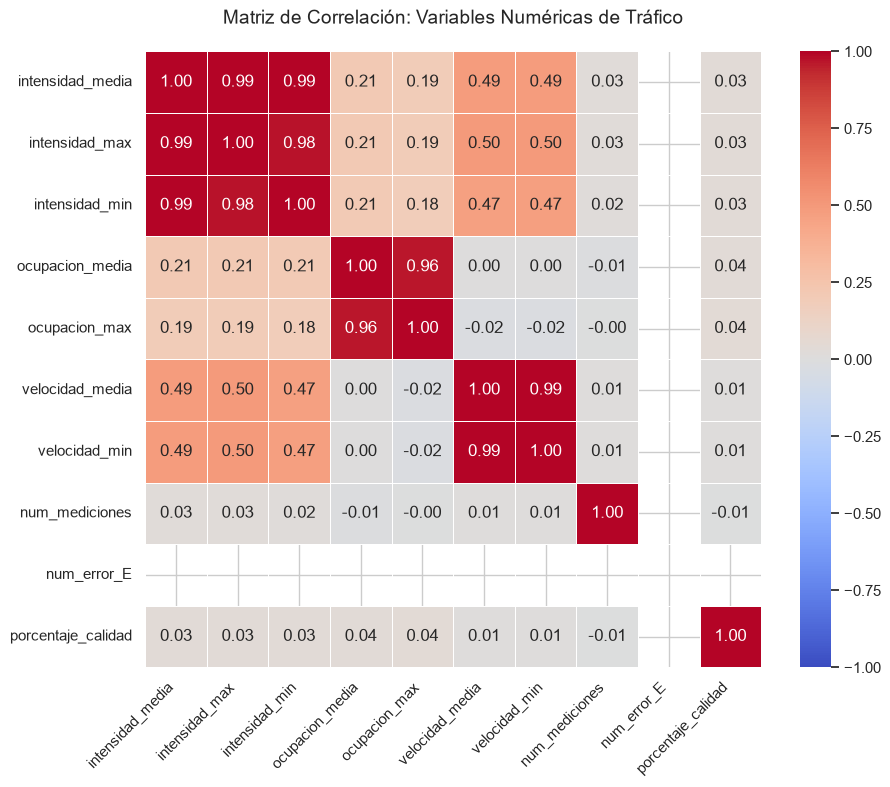

In [39]:
cols_numericas = [
    'intensidad_media', 'intensidad_max', 'intensidad_min',
    'ocupacion_media', 'ocupacion_max',
    'velocidad_media', 'velocidad_min',
    'num_mediciones', 'num_error_E', 'porcentaje_calidad'
]

# Traemos a memoria solo las columnas numéricas seleccionadas y luego calculamos la correlación
corr_df = df.select(cols_numericas).collect().corr()
corr_matrix_np = corr_df.to_numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_np, 
    xticklabels=cols_numericas,  
    yticklabels=cols_numericas, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    vmin=-1, vmax=1,     
    linewidths=0.5,      
    square=True          
)

plt.title('Matriz de Correlación: Variables Numéricas de Tráfico', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.show()

### Análisis de la Matriz de Correlación (Variables Numéricas)

Este mapa de calor (*heatmap*) representa los coeficientes de correlación de Pearson entre las variables continuas del dataset. Su análisis permite identificar relaciones lineales directas, redundancias en la información y características estructurales de los datos de sensórica.

**Hallazgos Analíticos Principales:**

*   **Varianza Cero (Anomalía Estructural):** La fila y columna correspondientes a `num_error_E` aparecen en blanco. Esto indica que la variable es constante en todo el conjunto de datos (probablemente compuesta íntegramente por ceros o valores nulos). Al no tener variación (desviación estándar igual a cero), es matemáticamente imposible calcular su correlación y debería ser eliminada en fases de modelado.
*   **Alta Multicolinealidad (Redundancia):** Se observan bloques granate de correlación casi perfecta (valores entre 0.96 y 0.99) dentro de las mismas familias de métricas. Por ejemplo, `intensidad_media` es prácticamente idéntica a `intensidad_max` y `intensidad_min`. Para evitar redundancia y sobreajuste en futuros algoritmos, sería recomendable conservar únicamente las métricas medias.
*   **Jerarquía Viaria (Intensidad vs. Velocidad):** Existe una correlación positiva moderada (0.49) entre el volumen de vehículos (`intensidad_media`) y la velocidad (`velocidad_media`). Esto no significa que a mayor atasco los coches vayan más rápido, sino que refleja la infraestructura de la ciudad: las vías que soportan mayor intensidad (avenidas, circunvalaciones) están diseñadas con límites de velocidad más altos que las vías de baja capacidad.
*   **Independencia del Hardware:** Las métricas de estado técnico, como `porcentaje_calidad` y `num_mediciones`, presentan una correlación prácticamente nula (cercana a 0.00) con las variables de tráfico. Esto es un indicador excelente, ya que demuestra que la capacidad del sensor para registrar datos de calidad no se ve afectada ni por la cantidad de coches ni por la velocidad a la que circulan.

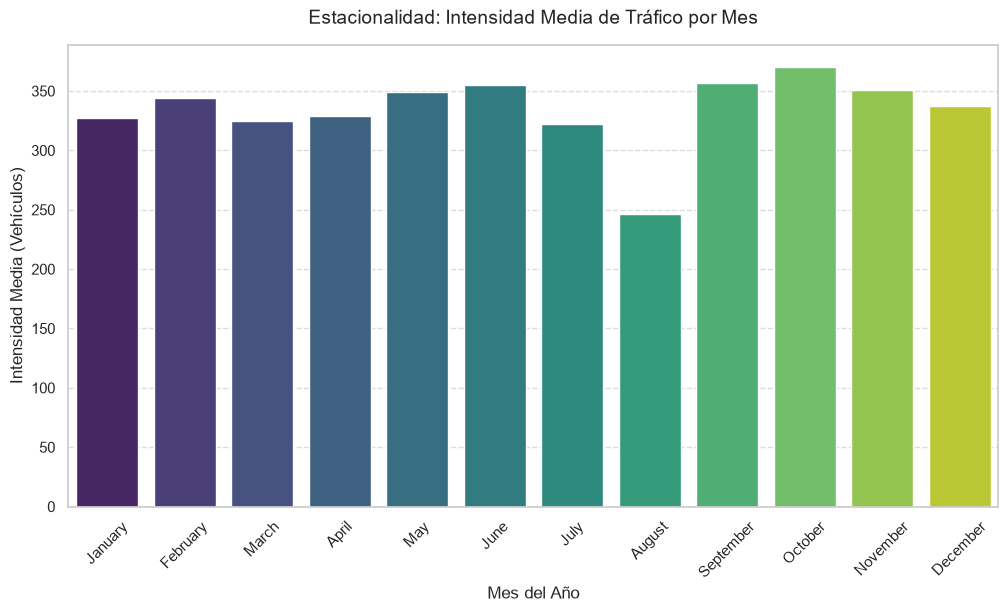

In [38]:
df_mes = (
    df.group_by(["mes", "nombre_mes"])
    .agg(pl.col("intensidad_media").mean())
    .sort("mes")
    .collect()
)

nombres_meses = df_mes["nombre_mes"].to_list()
intensidad = df_mes["intensidad_media"].to_list()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=nombres_meses, 
    y=intensidad, 
    hue=nombres_meses, 
    palette="viridis", 
    legend=False
)

plt.title('Estacionalidad: Intensidad Media de Tráfico por Mes', fontsize=14, pad=15)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Intensidad Media (Vehículos)', fontsize=12)
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.show()

### Análisis de Estacionalidad Mensual (Ciclo Anual)

Este gráfico de barras ilustra la evolución de la intensidad media del tráfico a lo largo del año. Al agregar los datos a nivel mensual, la visualización captura perfectamente los patrones macroscópicos de movilidad y el impacto directo del calendario socioeconómico en la ciudad.

**Patrones Estacionales Clave:**

*   **El Valle Estival (Agosto):** El hallazgo más evidente es la caída drástica del volumen de vehículos durante el mes de agosto, marcando el mínimo anual (por debajo de los 250 vehículos de media). Esto cuantifica el impacto del éxodo vacacional masivo, el cierre de los centros educativos y la paralización parcial de la actividad comercial.
*   **El Pico Máximo Otoñal (Octubre):** Octubre se posiciona como el mes de mayor carga viaria del año, superando los 360 vehículos de media. Este máximo refleja la ciudad a pleno rendimiento: rutinas laborales y escolares totalmente consolidadas, fin de las jornadas intensivas y un empeoramiento meteorológico que tradicionalmente incrementa el uso del vehículo privado.
*   **Antesala del Verano (Mayo - Junio):** Se observa una alta densidad sostenida en los meses previos al verano, operando casi a máxima capacidad operativa antes de iniciar el descenso paulatino en julio.
*   **Impacto de Festividades Intermitentes:** Las ligeras disminuciones relativas en meses como enero y marzo/abril evidencian el efecto de los periodos festivos cortos (vacaciones de Navidad y Semana Santa), que reducen la media mensual general en comparación con meses de calendario laboral continuo como febrero.

**Conclusión:** La demanda viaria no es un fenómeno lineal ni estático. Responde con extrema sensibilidad al ciclo sociolaboral, mostrando fluctuaciones predecibles que resultan vitales para cualquier estrategia de planificación urbana o control de tráfico a largo plazo.